# Analysing the Relationship Between Electricity Prices, Demand, and Weather in New Zealand

#### 1. Student name: 
#### 1. Student ID: 
#### 1. Responsible for content: Data Acquisition; Problem-solving and analysis of Question 1, 2, 3; Conclusion; Key Findings.

#### 2. Student name: Tilly
#### 2. Student ID: 
#### 2. Responsible for content: Introduction; Executive Summary; Data Wangling and EDA; Problem-solving and analysis of Question 4

# Introduction
Electricity prices in New Zealand can change a lot from one period to another. Sometimes the changes are small, but there can also be sudden price spikes in the electricity market. These spikes are often connected to high electricity demand and differences between regions in the electricity network.

Weather can matter too. Colder days, rainfall, humidity, and wind conditions may all be linked to changes in electricity demand across New Zealand. Demand levels can also vary quite a bit between different electricity nodes.

This project analyses the relationship between electricity prices, demand, and weather conditions in New Zealand using electricity market data and regional weather data collected across multiple nodes and time periods. The analysis combines data wrangling, exploratory data analysis, and statistical visualisations to investigate trends, patterns, and extreme electricity spike events.

The main goal of this project is to explore how demand, weather conditions, and regional factors are related to electricity price changes in New Zealand.

### Dataset sources: 
1. New Zealand Electricity Authority EMI (Electricity Market Information)
https://www.emi.ea.govt.nz/

2. Open-Meteo Historical Weather API
https://open-meteo.com/en/docs/historical-weather-api


### Research Questions

1. What relationships exist between weather conditions, electricity demand, and electricity prices in New Zealand?
2. How do seasonal and monthly demand patterns influence electricity price variation and high-price events in the selected area?
3. How do regional differences shape electricity price variation, demand levels, and high-price event risk in the selected area?
4. Under what combinations of demand, weather conditions, and regional factors are extreme electricity   price spikes most likely to occur?


### Executive Summary
This project examines the relationship between electricity prices, electricity demand, weather conditions, and regional factors in New Zealand. Electricity market data were combined with regional weather data to investigate patterns in electricity value and extreme price spikes. The analysis found that electricity demand has the strongest relationship with electricity value and spike events. Higher demand periods were associated with higher electricity values, particularly during winter. Spike events also occurred more often during high-demand periods. The highest spike proportions were observed in combinations with higher humidity and lower wind speeds. PEN0331 (Penrose, Auckland) experienced far more spike events than the other nodes.

# 1. Data Acquisition

In [1]:
import requests
from bs4 import BeautifulSoup
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

%matplotlib inline

pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 30)

rcParams['figure.figsize'] = 10, 6

In [2]:
def fetch_emi_data(show_value, value_name):
    url = "https://www.emi.ea.govt.nz/Wholesale/Reports/W_GD_C"

    params = {
        "DateFrom": "20230101",
        "DateTo": "20260101",
        "RegionType": "POC",
        "TimeScale": "DAY",
        "Show": show_value,
        "seriesFilter": "PEN0331,HAM0331,ALB0331,HEN0331,ROT0111",
        "_si": "v|3"
    }

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": "https://www.emi.ea.govt.nz/"
    }

    r = requests.get(url, params=params, headers=headers, timeout=300)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")

    script_text = None
    for script in soup.find_all("script"):
        text = script.get_text()
        if "var reportInfo" in text and "$reportInfo = reportInfo" in text:
            script_text = text
            break

    if script_text is None:
        raise ValueError("Cannot find reportInfo script")

    marker = "var reportInfo ="
    marker_pos = script_text.find(marker)
    start = script_text.find("{", marker_pos)

    brace_count = 0
    end = None

    for i in range(start, len(script_text)):
        char = script_text[i]

        if char == "{":
            brace_count += 1
        elif char == "}":
            brace_count -= 1

            if brace_count == 0:
                end = i + 1
                break

    if end is None:
        raise ValueError("Cannot find matching closing brace")

    raw_js_object = script_text[start:end]

    def convert_date(match):
        year = int(match.group(1))
        month = int(match.group(2)) + 1
        day = int(match.group(3))
        return f'"{year:04d}-{month:02d}-{day:02d}"'

    raw_json = re.sub(
        r"Date\.UTC\((\d{4}),\s*(\d{1,2}),\s*(\d{1,2})\)",
        convert_date,
        raw_js_object
    )

    raw_json = raw_json.replace("undefined", "null")

    report = json.loads(raw_json)

    rows = []

    for series in report["series"]:
        name = series.get("name")
        node = series.get("seriesIdentity")

        if node is None and name:
            node = name.split(" - ")[0]

        if series.get("data") is not None:
            for item in series.get("data", []):
                rows.append({
                    "date": item[0],
                    "node": node,
                    "name": name,
                    value_name: item[1]
                })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])

    return df


gwh_df = fetch_emi_data("Gwh", "Gwh")

dollar_df = fetch_emi_data("Dol", "Dol")

merged_df = gwh_df.merge(
    dollar_df[["date", "node", "Dol"]],
    on=["date", "node"],
    how="left"
)

print(merged_df.head())
print(merged_df.shape)

merged_df.to_csv("electricity_gwh_dollars.csv", index=False, encoding="utf-8-sig")

        date     node               name    Gwh        Dol
0 2023-01-01  PEN0331  PEN0331 - Penrose  2.573   10508.10
1 2023-01-02  PEN0331  PEN0331 - Penrose  2.665   29065.38
2 2023-01-03  PEN0331  PEN0331 - Penrose  2.767  139227.40
3 2023-01-04  PEN0331  PEN0331 - Penrose  3.120  152993.74
4 2023-01-05  PEN0331  PEN0331 - Penrose  3.254  169770.14
(5485, 5)


In [3]:
locations = {
    "PEN0331": {#In order to merge two CSV files easily, use the node of electricity station as the ID of each area, 
                #so that there is connection of the location.
        "place": "Penrose, Auckland",
        "latitude": -36.9100,
        "longitude": 174.8150
    },
    "HAM0331": {
        "place": "Hamilton",
        "latitude": -37.7870,
        "longitude": 175.2793
    },
    "ALB0331": {
        "place": "Albany, Auckland",
        "latitude": -36.7285,
        "longitude": 174.7072
    },
    "HEN0331": {
        "place": "Henderson, Auckland",
        "latitude": -36.8810,
        "longitude": 174.6300
    },
    "ROT0111": {
        "place": "Rotorua",
        "latitude": -38.1368,
        "longitude": 176.2497
    }
}

start_date = "2023-01-01"
end_date = "2026-01-11"

weather_rows = []

for node, info in locations.items():
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": info["latitude"],
        "longitude": info["longitude"],
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "rain_sum",
            "wind_speed_10m_mean",
            "relative_humidity_2m_mean"
        ],
        "timezone": "Pacific/Auckland"
    }

    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()

    data = response.json()
    daily = data["daily"]

    temp_df = pd.DataFrame(daily)
    temp_df["node"] = node
    temp_df["place"] = info["place"]
    temp_df["latitude"] = info["latitude"]
    temp_df["longitude"] = info["longitude"]

    weather_rows.append(temp_df)

weather_df = pd.concat(weather_rows, ignore_index=True)

weather_df = weather_df.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temp_mean",
    "temperature_2m_max": "temp_max",
    "temperature_2m_min": "temp_min",
    "precipitation_sum": "precipitation",
    "rain_sum": "rain",
    "wind_speed_10m_mean": "wind_speed",
    "relative_humidity_2m_mean": "humidity"
})

weather_df["date"] = pd.to_datetime(weather_df["date"])

print(weather_df.head())
print(weather_df.shape)

weather_df.to_csv("weather_data.csv", index=False, encoding="utf-8-sig")

        date  temp_mean  temp_max  temp_min  precipitation  rain  wind_speed  \
0 2023-01-01       18.8      21.3      16.4            0.2   0.2        16.8   
1 2023-01-02       18.4      20.2      16.8            1.1   1.1        25.5   
2 2023-01-03       19.2      21.6      17.3            0.9   0.9        34.5   
3 2023-01-04       18.9      19.9      18.4           19.1  19.1        41.9   
4 2023-01-05       19.6      20.3      19.0           27.6  27.6        38.9   

   humidity     node              place  latitude  longitude  
0        69  PEN0331  Penrose, Auckland    -36.91    174.815  
1        71  PEN0331  Penrose, Auckland    -36.91    174.815  
2        76  PEN0331  Penrose, Auckland    -36.91    174.815  
3        85  PEN0331  Penrose, Auckland    -36.91    174.815  
4        90  PEN0331  Penrose, Auckland    -36.91    174.815  
(5535, 12)


In [4]:
# Read electricity dataset using chunk-based processing
chunksize = 50000

electricity_chunks = []
for chunk in pd.read_csv("electricity_gwh_dollars.csv", chunksize=chunksize):
    electricity_chunks.append(chunk)

merged_df = pd.concat(electricity_chunks, ignore_index=True)

# Read weather dataset using chunk-based processing
weather_chunks = []
for chunk in pd.read_csv("weather_data.csv", chunksize=chunksize):
    weather_chunks.append(chunk)

weather_df = pd.concat(weather_chunks, ignore_index=True)

# Merge the datasets
merged_electricity_weather = weather_df.merge(
    merged_df[["date", "node", "name", "Gwh", "Dol"]],
    on=["date", "node"],
    how="left"
)

# Preview the merged dataset
print(merged_electricity_weather.head())
print(merged_electricity_weather.shape)

# Save the merged dataset
merged_electricity_weather.to_csv(
    "weather_electricity.csv",
    index=False,
    encoding="utf-8-sig"
)

         date  temp_mean  temp_max  temp_min  precipitation  rain  wind_speed  \
0  2023-01-01       18.8      21.3      16.4            0.2   0.2        16.8   
1  2023-01-02       18.4      20.2      16.8            1.1   1.1        25.5   
2  2023-01-03       19.2      21.6      17.3            0.9   0.9        34.5   
3  2023-01-04       18.9      19.9      18.4           19.1  19.1        41.9   
4  2023-01-05       19.6      20.3      19.0           27.6  27.6        38.9   

   humidity     node              place  latitude  longitude  \
0        69  PEN0331  Penrose, Auckland    -36.91    174.815   
1        71  PEN0331  Penrose, Auckland    -36.91    174.815   
2        76  PEN0331  Penrose, Auckland    -36.91    174.815   
3        85  PEN0331  Penrose, Auckland    -36.91    174.815   
4        90  PEN0331  Penrose, Auckland    -36.91    174.815   

                name    Gwh        Dol  
0  PEN0331 - Penrose  2.573   10508.10  
1  PEN0331 - Penrose  2.665   29065.38  
2  PE

# 2. Data Wrangling

In [5]:
df = merged_electricity_weather.copy()

# Rename for readability
df = df.rename(columns={
    'Gwh': 'demand_gwh',
    'Dol': 'total_electricity_value'
})

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Sort the data in time order
df = df.sort_values(by=['node', 'date']).reset_index(drop=True)

# Remove duplicates if any
df = df.drop_duplicates()

df.head()

,date,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity,node,place,latitude,longitude,name,demand_gwh,total_electricity_value
0,2023-01-01,19.0,21.1,17.3,0.0,0.0,21.5,66,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.231,5219.45
1,2023-01-02,18.3,19.9,17.0,3.0,3.0,30.3,70,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.284,14559.46
2,2023-01-03,18.9,20.6,17.6,3.4,3.4,34.6,77,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.327,69051.80
3,2023-01-04,18.5,19.6,17.7,28.1,28.1,41.8,89,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.440,71794.71
4,2023-01-05,19.4,20.1,18.7,32.7,32.7,38.5,93,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.487,79382.47


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5535 entries, 0 to 5534
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5535 non-null   datetime64[ns]
 1   temp_mean                5535 non-null   float64       
 2   temp_max                 5535 non-null   float64       
 3   temp_min                 5535 non-null   float64       
 4   precipitation            5535 non-null   float64       
 5   rain                     5535 non-null   float64       
 6   wind_speed               5535 non-null   float64       
 7   humidity                 5535 non-null   int64         
 8   node                     5535 non-null   object        
 9   place                    5535 non-null   object        
 10  latitude                 5535 non-null   float64       
 11  longitude                5535 non-null   float64       
 12  name                     5485 non-

In [7]:
df.describe()

,date,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity,latitude,longitude,demand_gwh,total_electricity_value
count,5535,5535.000000,5535.000000,5535.000000,5535.000000,5535.000000,5535.000000,5535.000000,5535.000000,5535.000000,5485.000000,5.485000e+03
mean,2024-07-07 00:00:00,14.867263,18.518826,11.509070,4.022511,4.021933,14.175989,80.902439,-37.288660,175.136240,1.825179,3.138342e+05
min,2023-01-01 00:00:00,4.100000,8.700000,-1.000000,0.000000,0.000000,2.100000,50.000000,-38.136800,174.630000,0.221000,2.930000e+00
25%,2023-10-04 00:00:00,12.150000,15.400000,8.700000,0.000000,0.000000,9.000000,76.000000,-37.787000,174.707200,1.397000,6.050182e+04
50%,2024-07-07 00:00:00,15.000000,18.300000,11.700000,0.600000,0.600000,13.100000,81.000000,-36.910000,174.815000,1.700000,2.381095e+05
75%,2025-04-10 00:00:00,18.100000,21.600000,14.700000,3.600000,3.600000,18.100000,87.000000,-36.881000,175.279300,2.119000,4.342893e+05
max,2026-01-11 00:00:00,23.100000,29.100000,21.100000,112.000000,112.000000,53.200000,100.000000,-36.728500,176.249700,4.799000,3.997496e+06
std,NaN,3.784963,3.888288,4.126181,8.659739,8.658853,6.699853,7.812786,0.564149,0.600689,1.087409,3.458939e+05


In [8]:
df.shape

(5535, 15)

### Missing values and simple cleaning

The merged dataset contained a small number of missing values after the weather and electricity data were combined. Most of the missing values were found in the electricity demand and electricity value columns. These values were replaced using the median for the corresponding month. The median was used because electricity demand and electricity value can vary across the year, so values from the same month were considered more suitable. The missing values were then checked again to make sure the columns were complete before the analysis continued.

In [9]:
df.isnull().sum()

date                        0
temp_mean                   0
temp_max                    0
temp_min                    0
precipitation               0
rain                        0
wind_speed                  0
humidity                    0
node                        0
place                       0
latitude                    0
longitude                   0
name                       50
demand_gwh                 50
total_electricity_value    50
dtype: int64

In [10]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [11]:
# Fill missing values using monthly median values
df['demand_gwh'] = df['demand_gwh'].fillna(
    df.groupby('month')['demand_gwh'].transform('median'))
df['total_electricity_value'] = df['total_electricity_value'].fillna(
    df.groupby('month')['total_electricity_value'].transform('median'))
# Check remaining missing values
df.isnull().sum()

date                        0
temp_mean                   0
temp_max                    0
temp_min                    0
precipitation               0
rain                        0
wind_speed                  0
humidity                    0
node                        0
place                       0
latitude                    0
longitude                   0
name                       50
demand_gwh                  0
total_electricity_value     0
year                        0
month                       0
dtype: int64

In [12]:
# Keep the dataset tidy
df = df.dropna(how='all')

### User-defined functions

In [13]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

### Creating New Variables

In [14]:
df['month_name'] = df['date'].dt.strftime('%b')
df['weekday'] = df['date'].dt.day_name()
df['season'] = df['month'].apply(get_season)

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
# Rank prices to identify spikes
df['price_rank'] = df['total_electricity_value'].rank(ascending=False)

# Flag the top 5% price observations
price_threshold = df['total_electricity_value'].quantile(0.95)
df['high_price_flag'] = np.where(df['total_electricity_value'] >= price_threshold, 'Top 5%', 'Other')

df.head()

,date,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity,node,place,latitude,longitude,name,demand_gwh,total_electricity_value,year,month,month_name,weekday,season,price_rank,high_price_flag
0,2023-01-01,19.0,21.1,17.3,0.0,0.0,21.5,66,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.231,5219.45,2023,1,Jan,Sunday,Summer,5255.0,Other
1,2023-01-02,18.3,19.9,17.0,3.0,3.0,30.3,70,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.284,14559.46,2023,1,Jan,Monday,Summer,5004.0,Other
2,2023-01-03,18.9,20.6,17.6,3.4,3.4,34.6,77,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.327,69051.80,2023,1,Jan,Tuesday,Summer,4021.0,Other
3,2023-01-04,18.5,19.6,17.7,28.1,28.1,41.8,89,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.440,71794.71,2023,1,Jan,Wednesday,Summer,3989.0,Other
4,2023-01-05,19.4,20.1,18.7,32.7,32.7,38.5,93,ALB0331,"Albany, Auckland",-36.7285,174.7072,ALB0331 - Albany,1.487,79382.47,2023,1,Jan,Thursday,Summer,3888.0,Other


### Time series preparation

In [15]:
# National daily averages across all nodes
daily_df = df.groupby('date')[[
    'demand_gwh', 'total_electricity_value', 'temp_mean', 'temp_max', 'temp_min',
    'precipitation', 'rain', 'wind_speed', 'humidity'
]].mean()

daily_df.head()

,demand_gwh,total_electricity_value,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity
date,,,,,,,,,
2023-01-01,1.2728,5240.502,17.90,20.94,15.10,0.04,0.04,16.02,66.6
2023-01-02,1.3176,14578.888,17.50,20.02,15.04,1.20,1.20,22.64,72.2
2023-01-03,1.3634,69251.542,18.18,20.70,16.14,1.70,1.70,29.44,77.8
2023-01-04,1.4962,73208.026,17.76,18.84,17.00,18.28,18.28,35.56,87.6
2023-01-05,1.5476,80926.502,18.52,19.46,17.64,32.10,32.10,33.82,92.4


In [16]:
# Monthly averages
monthly_df = daily_df.resample('ME').mean()
monthly_df.head()

,demand_gwh,total_electricity_value,temp_mean,temp_max,temp_min,precipitation,rain,wind_speed,humidity
date,,,,,,,,,
2023-01-31,1.593458,206128.067097,18.889677,21.603226,16.512903,10.226452,10.226452,17.763871,82.187097
2023-02-28,1.722486,272040.434786,18.675714,21.797857,16.047857,9.642857,9.642857,15.896429,82.857143
2023-03-31,1.674497,271837.749548,16.849677,20.840645,13.204516,2.692258,2.692258,11.325161,80.748387
2023-04-30,1.627713,168535.358267,16.370667,19.408667,13.742667,3.813333,3.813333,16.994667,82.873333
2023-05-31,1.861813,148245.981871,14.386452,17.029677,12.064516,6.993548,6.993548,17.818065,87.296774


In [17]:
# 7-day rolling mean for smoother time series
rolling_df = daily_df[['demand_gwh', 'total_electricity_value', 'temp_mean']].rolling(window=7).mean()
rolling_df.head(10)

,demand_gwh,total_electricity_value,temp_mean
date,,,
2023-01-01,NaN,NaN,NaN
2023-01-02,NaN,NaN,NaN
2023-01-03,NaN,NaN,NaN
2023-01-04,NaN,NaN,NaN
2023-01-05,NaN,NaN,NaN
2023-01-06,NaN,NaN,NaN
2023-01-07,1.433800,53544.700857,18.382857
2023-01-08,1.464886,55488.866857,18.737143
2023-01-09,1.512286,60413.396571,19.174286


### Summary tables

In [18]:
node_summary = df[['node', 'demand_gwh', 'total_electricity_value', 'temp_mean']].groupby('node').agg(['mean', 'median', 'min', 'max'])
node_summary

demand_gwh                      total_electricity_value             \
              mean median    min    max                    mean     median   
node                                                                         
ALB0331   1.719574  1.678  1.179  2.564           302271.019521  266888.49   
HAM0331   1.824148  1.792  1.243  2.552           308599.329648  275184.09   
HEN0331   1.648165  1.611  1.050  2.366           283426.937245  246524.28   
PEN0331   3.594902  3.600  1.496  4.799           617427.719910  562032.84   
ROT0111   0.324238  0.294  0.221  1.496            53140.359693   44767.95   

                            temp_mean                    
           min         max       mean median  min   max  
node                                                     
ALB0331  14.56  2235828.09  15.564770   15.5  7.0  22.9  
HAM0331  16.05  2108067.22  14.509575   14.7  5.2  23.1  
HEN0331  17.08  1980455.35  15.282294   15.2  7.0  22.7  
PEN0331  30.47  3997495.93  15.844535   15.8  7.5  23.1  
ROT0111   2.93   373907.23  13.135140   13.2  4.1  21.9

In [19]:
season_summary = df[['season', 'demand_gwh', 'total_electricity_value', 'temp_mean']].groupby('season', observed=False).agg(['mean', 'median', 'min', 'max'])
season_summary

demand_gwh                       total_electricity_value              \
             mean  median    min    max                    mean      median   
season                                                                        
Autumn   1.755836  1.6430  0.231  4.551           383415.028543  337466.770   
Spring   1.785933  1.6690  0.221  4.577           170538.610659  133592.280   
Summer   1.650284  1.5375  0.226  4.025           244756.000674  207201.505   
Winter   2.100110  2.0070  0.312  4.799           453117.432094  320469.620   

                            temp_mean                     
           min         max       mean median   min   max  
season                                                    
Autumn  799.41  3286465.09  15.455217   15.8   5.9  21.3  
Spring   85.85  1612912.13  14.227473   14.1   6.7  21.3  
Summer    2.93  1928992.16  18.928723   19.0  12.6  23.1  
Winter  239.54  3997495.93  10.762391   10.8   4.1  17.8

In [20]:
node_season_summary = df.groupby(['node', 'season'], observed=False)[['demand_gwh', 'total_electricity_value']].mean().reset_index()
node_season_summary

,node,season,demand_gwh,total_electricity_value
0,ALB0331,Autumn,1.669272,367508.044964
1,ALB0331,Spring,1.674410,165303.696996
2,ALB0331,Summer,1.551996,235457.117589
3,ALB0331,Winter,1.985768,440778.919420
4,HAM0331,Autumn,1.758949,377711.502935
5,HAM0331,Spring,1.737147,163211.026703
6,HAM0331,Summer,1.681766,246216.348050
7,HAM0331,Winter,2.120880,447034.285036
8,HEN0331,Autumn,1.544058,346645.385435
9,HEN0331,Spring,1.655403,154686.693443


### Pivot tables and cross-tabulation

In [21]:
price_pivot = df.pivot_table(
    values='total_electricity_value',
    index='node',
    columns='season',
    aggfunc='mean'
)

price_pivot

season,Autumn,Spring,Summer,Winter
node,,,,
ALB0331,367508.044964,165303.696996,235457.117589,440778.919420
HAM0331,377711.502935,163211.026703,246216.348050,447034.285036
HEN0331,346645.385435,154686.693443,214165.481950,418316.521486
PEN0331,763108.270543,341766.315861,485956.634681,878741.406014
ROT0111,62101.938841,27725.320293,41984.421099,80716.028514


In [22]:
demand_pivot = df.pivot_table(
    values='demand_gwh',
    index='node',
    columns='season',
    aggfunc='mean'
)

demand_pivot

season,Autumn,Spring,Summer,Winter
node,,,,
ALB0331,1.669272,1.674410,1.551996,1.985768
HAM0331,1.758949,1.737147,1.681766,2.120880
HEN0331,1.544058,1.655403,1.475355,1.921681
PEN0331,3.510917,3.557081,3.239798,4.079120
ROT0111,0.295986,0.305626,0.302507,0.393101


In [23]:
price_crosstab = pd.crosstab(df['season'], df['high_price_flag'])
price_crosstab

high_price_flag,Other,Top 5%
season,,
Autumn,1279,101
Spring,1364,1
Summer,1380,30
Winter,1235,145


### Identify the highest price days

In [24]:
top_price_days = df[['date', 'node', 'place', 'total_electricity_value', 'demand_gwh', 'temp_mean']].sort_values(
    by='total_electricity_value',
    ascending=False
).head(5)

top_price_days

,date,node,place,total_electricity_value,demand_gwh,temp_mean
3905,2024-08-07,PEN0331,"Penrose, Auckland",3997495.93,4.434,9.2
3904,2024-08-06,PEN0331,"Penrose, Auckland",3883853.86,4.401,9.8
3906,2024-08-08,PEN0331,"Penrose, Auckland",3737195.47,4.482,10.8
3903,2024-08-05,PEN0331,"Penrose, Auckland",3596392.48,4.406,9.0
3907,2024-08-09,PEN0331,"Penrose, Auckland",3307643.02,4.230,10.3


In [25]:
df[['date', 'node', 'place', 'total_electricity_value', 'price_rank']].sort_values(by='price_rank').head(5)

,date,node,place,total_electricity_value,price_rank
3905,2024-08-07,PEN0331,"Penrose, Auckland",3997495.93,1.0
3904,2024-08-06,PEN0331,"Penrose, Auckland",3883853.86,2.0
3906,2024-08-08,PEN0331,"Penrose, Auckland",3737195.47,3.0
3903,2024-08-05,PEN0331,"Penrose, Auckland",3596392.48,4.0
3907,2024-08-09,PEN0331,"Penrose, Auckland",3307643.02,5.0


### Save the cleaned dataset

In [26]:
df.to_csv("weather_electricity_cleaned.csv", index=False, encoding="utf-8-sig")
daily_df.to_csv("daily_national_trends.csv", encoding="utf-8-sig")

In [27]:
list(df.columns)

['date',
 'temp_mean',
 'temp_max',
 'temp_min',
 'precipitation',
 'rain',
 'wind_speed',
 'humidity',
 'node',
 'place',
 'latitude',
 'longitude',
 'name',
 'demand_gwh',
 'total_electricity_value',
 'year',
 'month',
 'month_name',
 'weekday',
 'season',
 'price_rank',
 'high_price_flag']

# 3. EDA

### Distribution of electricity prices

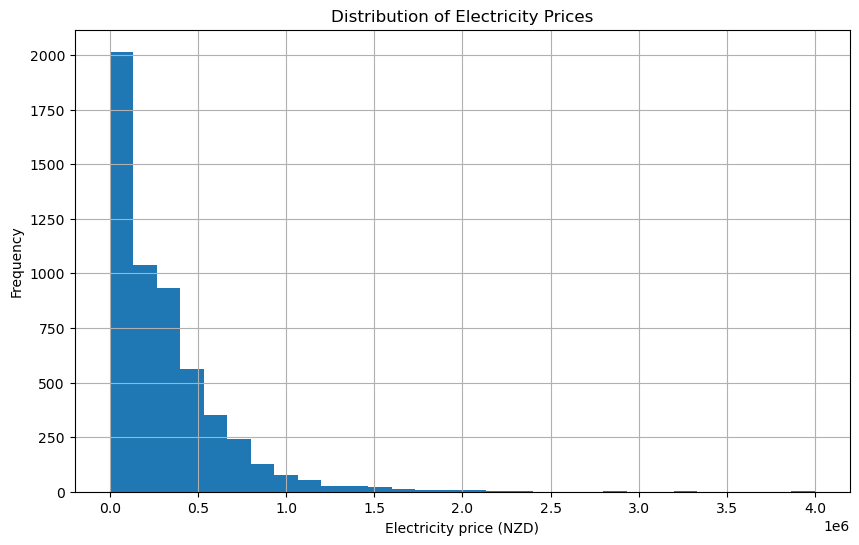

In [28]:
df['total_electricity_value'].hist(bins=30)
plt.title('Distribution of Electricity Prices')
plt.xlabel('Electricity price (NZD)')
plt.ylabel('Frequency')
plt.show()

Most electricity prices are concentrated at the lower end of the distribution. A small number of very high values appear on the right side of the graph. Very high prices do appear in the dataset, but there are not many of them.

### Electricity price by node

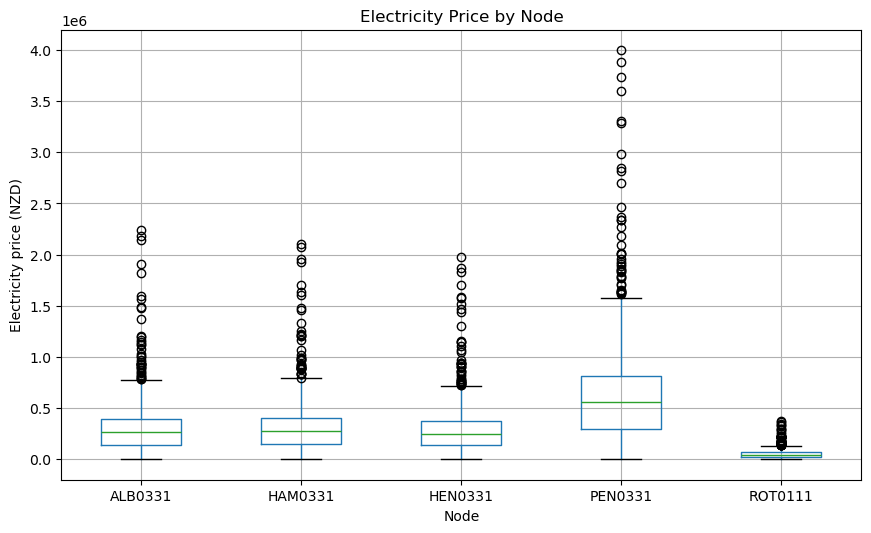

In [29]:
df[['node', 'total_electricity_value']].boxplot(by='node')
plt.title('Electricity Price by Node')
plt.suptitle('')
plt.xlabel('Node')
plt.ylabel('Electricity price (NZD)')
plt.show()

PEN0331 has the highest prices in the graph. The values are spread across a much wider range, and there are many points above the main box. ROT0111 looks quite different, with lower prices and a much smaller spread. This means that price levels are not the same across the nodes.

### Boxplot of demand by season

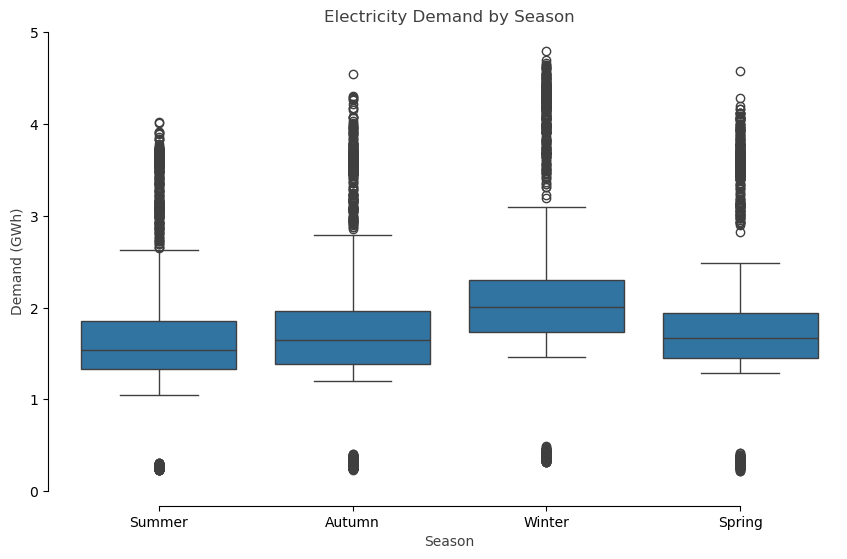

In [30]:
sns.boxplot(x='season', y='demand_gwh', data=df)
sns.despine(offset=10, trim=True)

plt.title('Electricity Demand by Season', alpha=0.75, fontsize=12)
plt.xlabel('Season', alpha=0.75)
plt.ylabel('Demand (GWh)', alpha=0.75)
plt.show()

Winter has the highest median electricity demand. The spread of the data is also larger in Winter than in the other seasons. There are more high-demand values in Winter, while the other seasons are more similar to each other. This shows that the effect of season is seen in both the demand level and the variation in demand.

### Monthly Trends in Demand, Total Electricity Value, and Temperature

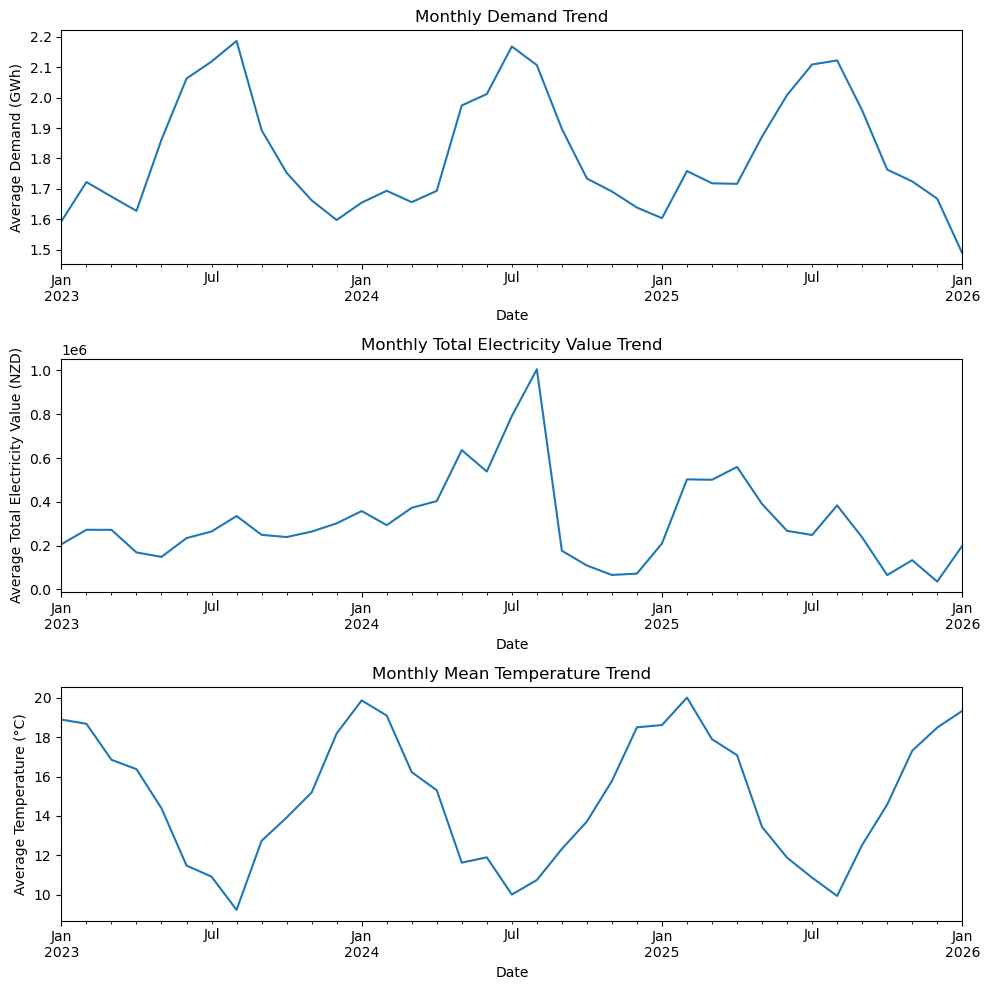

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
# Monthly demand trend
monthly_df['demand_gwh'].plot(ax=axes[0])
axes[0].set_title('Monthly Demand Trend')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Demand (GWh)')

# Monthly total electricity value trend
monthly_df['total_electricity_value'].plot(ax=axes[1])
axes[1].set_title('Monthly Total Electricity Value Trend')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Total Electricity Value (NZD)')

# Monthly temperature trend
monthly_df['temp_mean'].plot(ax=axes[2])
axes[2].set_title('Monthly Mean Temperature Trend')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

From the graphs, demand is usually higher around July and August. The temperature graph reaches its lowest values at about the same time. This happens in all three years. The electricity value graph looks different. August 2024 jumps well above the surrounding months. Nothing else in the graph changes by a similar amount.

### Electricity price versus temperature

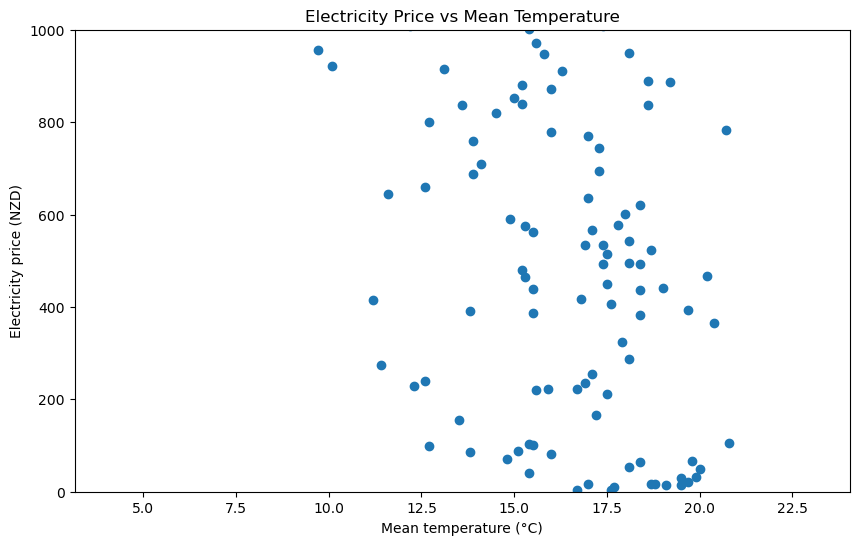

In [32]:
plt.scatter(df['temp_mean'], df['total_electricity_value'])
plt.title('Electricity Price vs Mean Temperature')
plt.xlabel('Mean temperature (°C)')
plt.ylabel('Electricity price (NZD)')
plt.ylim(0, 1000)
plt.show()

From the scatter plot, most of the points are grouped between 15°C and 20°C. For example, around 18°C there are points near the bottom of the graph and others close to 1000 NZD. Temperature alone does not seem to explain these differences.

### Correlation analysis

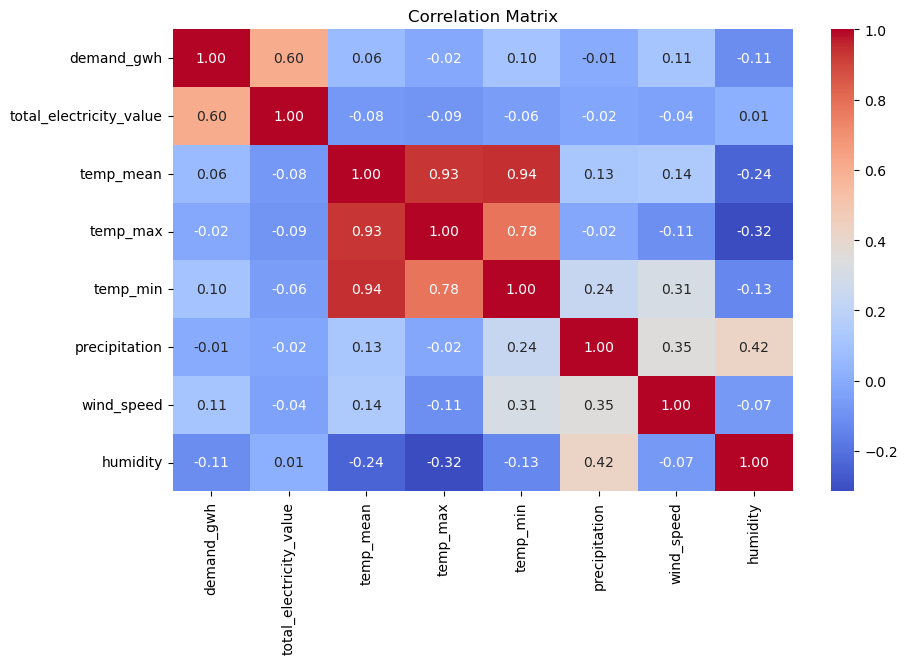

In [33]:
corr_cols = [
    'demand_gwh', 'total_electricity_value', 'temp_mean', 'temp_max', 'temp_min',
    'precipitation', 'wind_speed', 'humidity'
]

corr = df[corr_cols].corr()
corr

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# 4. Analysis

#### Questionn 1. What relationships exist between weather conditions, electricity demand, and electricity prices in New Zealand?

Looking at the correlation matrix, demand_gwh and total_electricity_value have a correlation of 0.60. This is higher than many of the other relationships in the matrix. Temp_mean, temp_max, and temp_min are also closely related. All three variables measure temperature. The weather variables do not seem to have much of a relationship with demand. Their correlation values are all quite small, including temperature, precipitation, wind speed, and humidity. Looking at the matrix, weather on its own does not appear to explain much of the variation in electricity demand.

#### Question 2. How do seasonal and monthly demand patterns influence electricity price variation and high-price events in New Zealand?

In [34]:
#Set the highest 5% total electricity price as the high-price events.
price_threshold = df["total_electricity_value"].quantile(0.95)

df["high_price_event"] = np.where(
    df["total_electricity_value"] >= price_threshold,
    1,
    0
)

print("High price threshold:", price_threshold)
print(df["high_price_event"].value_counts()) #The number of high price events.

High price threshold: 924050.202
high_price_event
0    5258
1     277
Name: count, dtype: int64


To explore high-price events, observations in the top 5% of total electricity values were classified as high-price events.

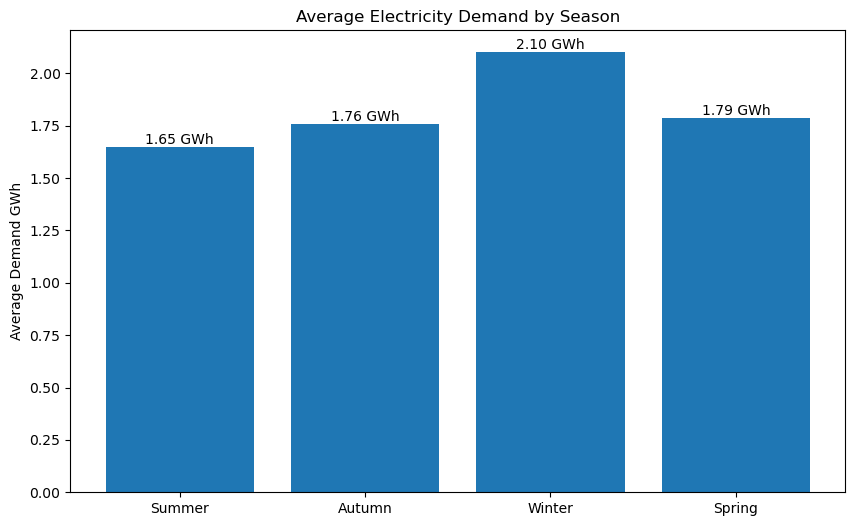

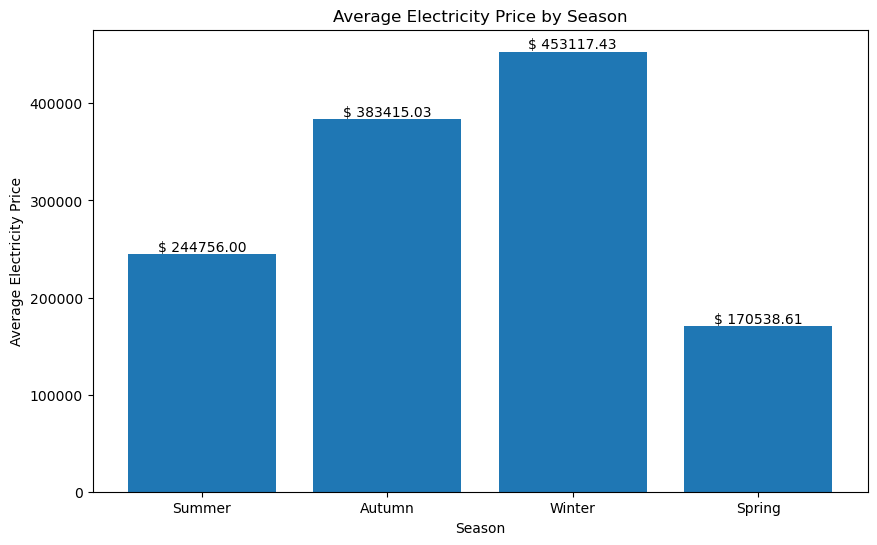

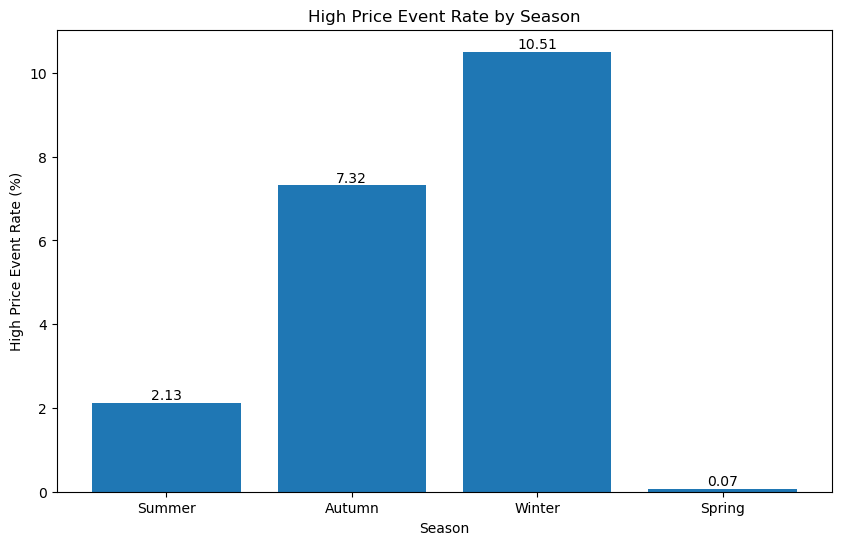

In [35]:
season_summary = df.groupby("season").agg(
    avg_price=("total_electricity_value", "mean"),
    avg_demand=("demand_gwh", "mean"),
    high_price_rate=("high_price_event", "mean")
).reset_index()

season_summary["high_price_rate"] = season_summary["high_price_rate"] * 100

season_summary

season_order = ["Summer", "Autumn", "Winter", "Spring"]

season_summary["season"] = pd.Categorical(
    season_summary["season"],
    categories=season_order,
    ordered=True
)

season_summary = season_summary.sort_values("season")

plt.figure()
bars = plt.bar(
    season_summary["season"],
    season_summary["avg_demand"]
)
plt.ylabel("Average Demand GWh")
plt.title("Average Electricity Demand by Season")
for season, value in zip(season_summary["season"], season_summary["avg_demand"]):
    plt.text(
        season,
        value,
        f"{value:.2f} GWh",
        ha="center",
        va="bottom"
    )
plt.show()

plt.figure()
bars = plt.bar(
    season_summary["season"],
    season_summary["avg_price"]
)
plt.xlabel("Season")
plt.ylabel("Average Electricity Price")
plt.title("Average Electricity Price by Season")
for season, value in zip(season_summary["season"], season_summary["avg_price"]):
    plt.text(
        season,
        value,
        f"$ {value:.2f}",
        ha="center",
        va="bottom"
    )
plt.show()

plt.figure()
bars = plt.bar(
    season_summary["season"],
    season_summary["high_price_rate"]
)
plt.xlabel("Season")
plt.ylabel("High Price Event Rate (%)")
plt.title("High Price Event Rate by Season")
for season, value in zip(season_summary["season"], season_summary["high_price_rate"]):
    plt.text(
        season,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )
plt.show()

From the seasonal charts, winter has the highest average electricity demand and the highest average electricity price. Winter demand is around 2.1 
GWh, which is higher than the other seasons. At the same time, winter also has the highest average electricity price, at around $450,000.

The high-price event rate also supports this pattern. The high price events are more likely to happen in winter, and the chance is at around 10%, while autumn is lower at around 7%. Summer has a much lower rate, and spring has almost no high-price events. This means that high-price events are not evenly distributed across seasons.

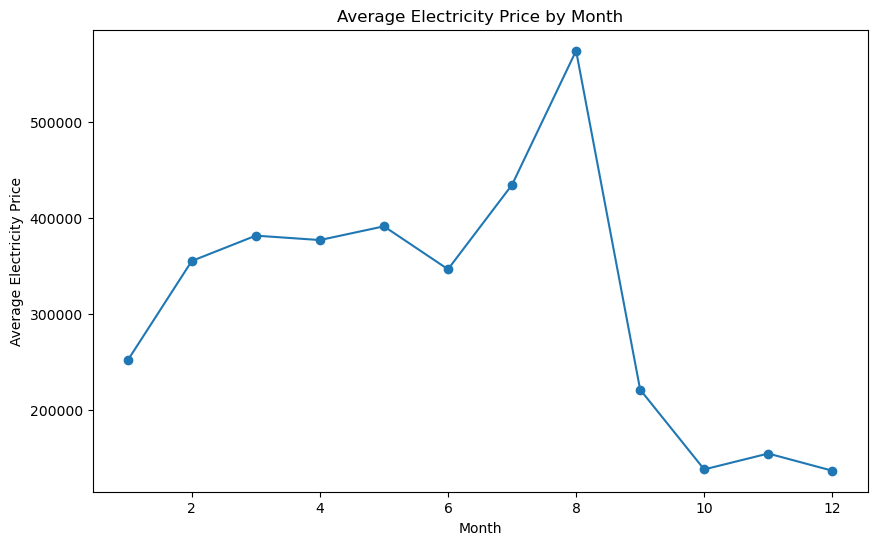

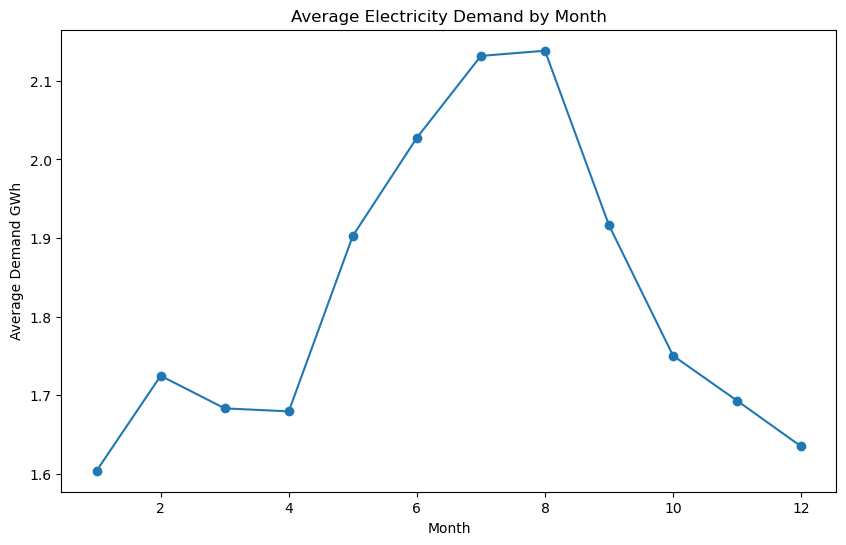

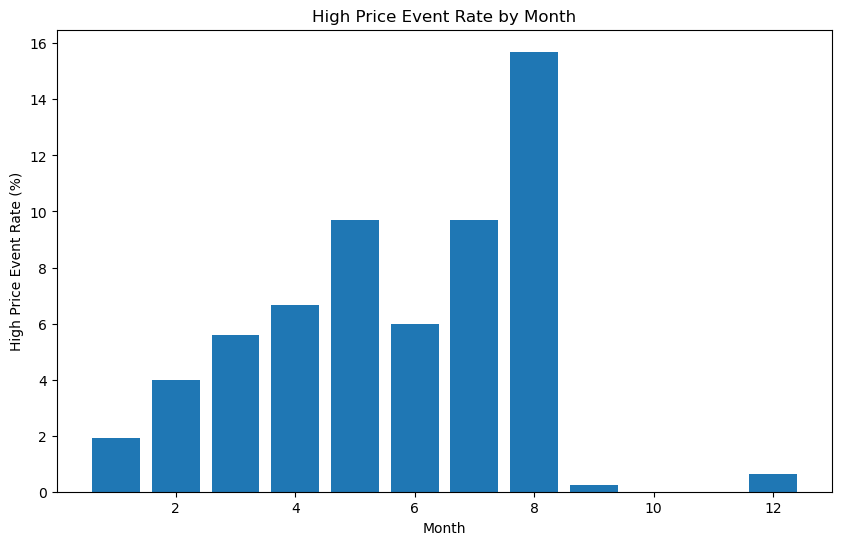

In [36]:
#Calculate average total price, average demand, and average rate of high price event of each month.
monthly_summary = df.groupby("month").agg(
    avg_price=("total_electricity_value", "mean"),
    avg_demand=("demand_gwh", "mean"),
    high_price_rate=("high_price_event", "mean") 
).reset_index() 
 #In the column 'high_price_event, high price events show value 1, other price show value 0. 
 #'high_price_rate' is the rate of high price event in each month by calculating the mean value. 
    
monthly_summary["high_price_rate"] = monthly_summary["high_price_rate"] * 100

monthly_summary

import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_summary["month"], monthly_summary["avg_price"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Electricity Price")
plt.title("Average Electricity Price by Month")
plt.show()

plt.figure()
plt.plot(monthly_summary["month"], monthly_summary["avg_demand"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Demand GWh")
plt.title("Average Electricity Demand by Month")
plt.show()

plt.figure()
plt.bar(monthly_summary["month"], monthly_summary["high_price_rate"])
plt.xlabel("Month")
plt.ylabel("High Price Event Rate (%)")
plt.title("High Price Event Rate by Month")
plt.show()

The monthly charts give more detailed evidence. Average demand rises from May and reaches its highest level in July and August. Average electricity price follows a similar trend and peaks in August. The high-price event rate is also highest in August, at around 16%. This shows that the winter pattern is mainly driven by July and especially August.

**Summary:** The results suggest that seasonal demand patterns are closely related to electricity price variation and high-price events. When demand increases in winter, electricity prices also tend to increase, and the chance of high-price events becomes higher. And the winter pattern is mainly driven by July and especially August.

#### Question 3. How do regional differences shape electricity price variation, demand levels, and high-price event risk in the selected area?

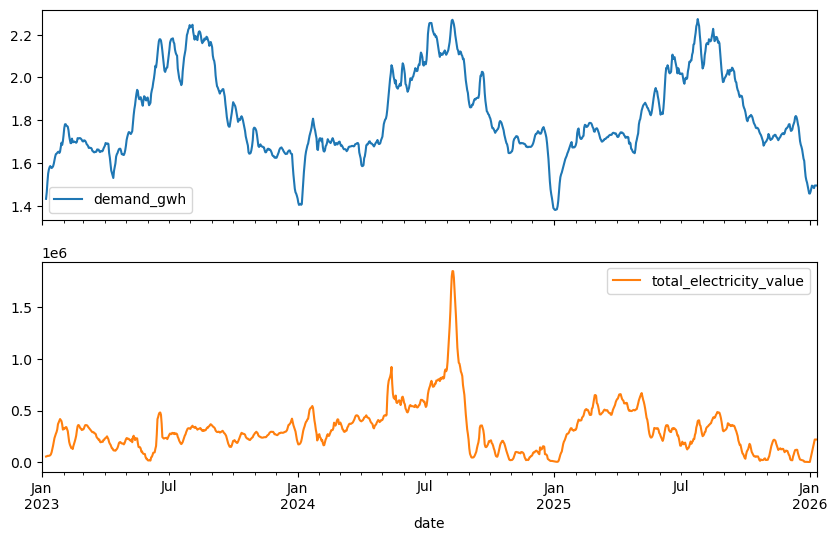

In [37]:
daily_df[['demand_gwh', 'total_electricity_value']].rolling(window=7).mean().plot(subplots=True)
plt.show()

The time series plot shows that electricity demand follows a clear seasonal pattern. Demand generally increases during the winter months, especially around June to August, and decreases as it getting warmer. This suggests that winter demand is higher, probably because the needs of heating increase..

Electricity price also shows seasonal movement, but it is more volatile than demand. In August 2024, there was a price spike as the electricity demand seems normal and similar as the usage of the other years. This supports the earlier seasonal and monthly results, which showed that winter and August have the highest average price and high-price event rate.

However, the relationship between demand and price is not perfectly consistent. Other winter periods also show high demand, but they do not produce the same extreme price spike as 2024. Therefore, demand appears to be associated with price increases, but it does not fully explain extreme high-price events. 

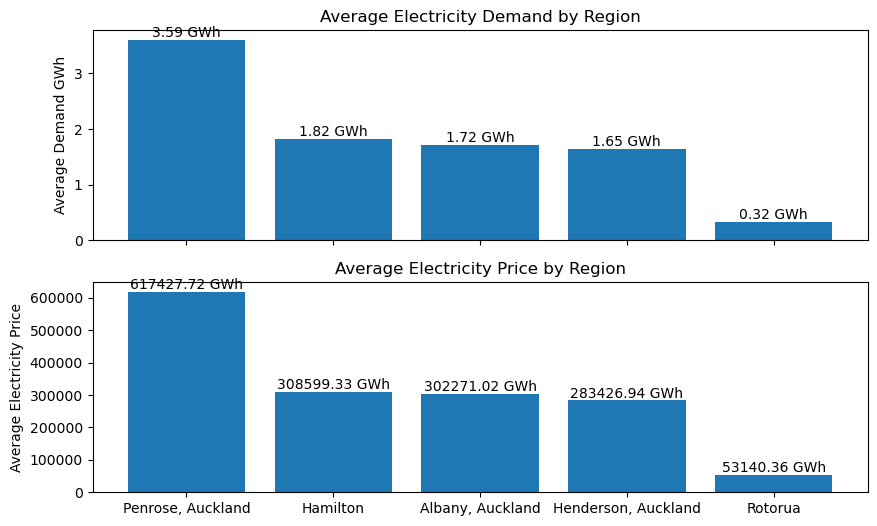

In [38]:
#Summarise the high average total electricity price, average electricity demand and high price event by place.
region_summary = df.groupby("place").agg(
    avg_price=("total_electricity_value", "mean"),
    avg_demand=("demand_gwh", "mean"),
    high_price_rate=("high_price_event", "mean"),
).reset_index()

region_summary["high_price_rate"] = region_summary["high_price_rate"] * 100

region_summary = region_summary.sort_values("avg_price", ascending=False)

region_summary

#Plot the average total electricity price of different place.
fig, axes = plt.subplots(2, 1, sharex=True)

axes[0].bar(region_summary["place"], region_summary["avg_demand"])
axes[0].set_ylabel("Average Demand GWh")
axes[0].set_title("Average Electricity Demand by Region")
for place, value in zip(region_summary["place"], region_summary["avg_demand"]):
    axes[0].text(
        place,
        value,
        f"{value:.2f} GWh",
        ha="center",
        va="bottom"
    )

axes[1].bar(region_summary["place"], region_summary["avg_price"])
axes[1].set_ylabel("Average Electricity Price")
axes[1].set_title("Average Electricity Price by Region")
for place, value in zip(region_summary["place"], region_summary["avg_price"]):
    axes[1].text(
        place,
        value,
        f"{value:.2f} GWh",
        ha="center",
        va="bottom"
    )

plt.show()

The results show clear regional differences in both electricity price and electricity demand.

From the first chart, Penrose, Auckland has the highest average demand, around 3.6 GWh, which is almost twice of Hamilton. Hamilton, Albany, and Henderson have moderate demand, while Rotorua has the lowest demand. 

The average total electricity price plot shows that Penrose, Auckland also has the highest average electricity price, at over 600,000. This is much higher than the other regions. Hamilton, Albany, and Henderson have similar average prices, around 280,000 to 310,000. Rotorua has the lowest average electricity price, only around 50,000. This suggests that regions with higher electricity demand also tend to have higher total electricity value.

                  place  season      avg_price  avg_demand  high_price_rate
2      Albany, Auckland  Summer  235457.117589    1.551996         0.000000
0      Albany, Auckland  Autumn  367508.044964    1.669272         1.086957
3      Albany, Auckland  Winter  440778.919420    1.985768         8.333333
1      Albany, Auckland  Spring  165303.696996    1.674410         0.000000
6              Hamilton  Summer  246216.348050    1.681766         0.354610
4              Hamilton  Autumn  377711.502935    1.758949         1.086957
7              Hamilton  Winter  447034.285036    2.120880         7.246377
5              Hamilton  Spring  163211.026703    1.737147         0.000000
10  Henderson, Auckland  Summer  214165.481950    1.475355         0.000000
8   Henderson, Auckland  Autumn  346645.385435    1.544058         1.449275
11  Henderson, Auckland  Winter  418316.521486    1.921681         6.521739
9   Henderson, Auckland  Spring  154686.693443    1.655403         0.000000
14    Penros

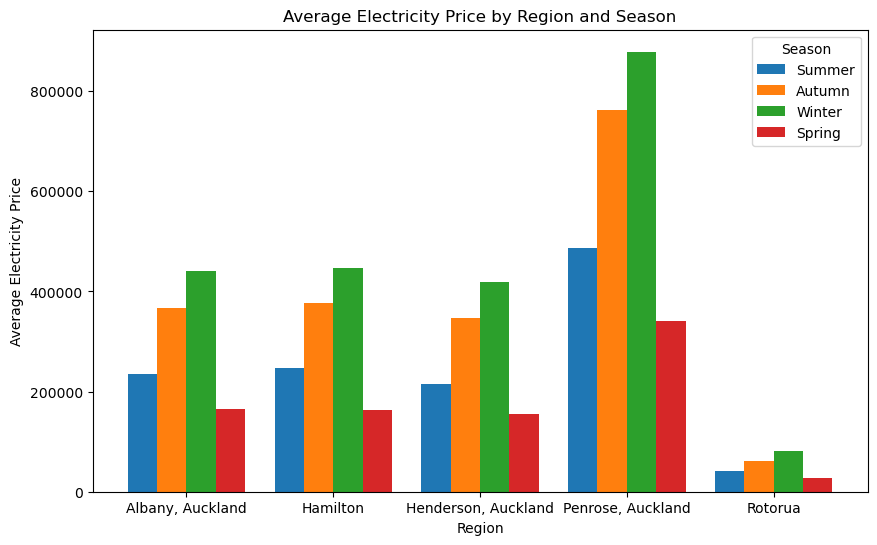

In [39]:
region_season_summary = df.groupby(["place", "season"]).agg(
    avg_price=("total_electricity_value", "mean"),
    avg_demand=("demand_gwh", "mean"),
    high_price_rate=("high_price_event", "mean")
).reset_index()

region_season_summary["high_price_rate"] = region_season_summary["high_price_rate"] * 100

season_order = ["Summer", "Autumn", "Winter", "Spring"]

region_season_summary["season"] = pd.Categorical(
    region_season_summary["season"],
    categories=season_order,
    ordered=True
)

region_season_summary = region_season_summary.sort_values(["place", "season"])

region_season_table = region_season_summary.rename(columns={
    "place": "Region",
    "season": "Season",
    "avg_price": "Average Total Electricity Value",
    "avg_demand": "Average Demand GWh",
    "high_price_rate": "High Price Event Rate (%)"
})
print(region_season_summary)

places = region_season_summary["place"].unique()

x = np.arange(len(places))
width = 0.2

for i, season in enumerate(season_order):
    temp = region_season_summary[region_season_summary["season"] == season]
    
    plt.bar(
        x + i * width,
        temp["avg_price"],
        width,
        label=season
    )

plt.xlabel("Region")
plt.ylabel("Average Electricity Price")
plt.title("Average Electricity Price by Region and Season")
plt.xticks(x + width * 1.5, places)
plt.legend(title="Season")
plt.show()

The grouped bar chart shows the average total electricity price by region and season. Overall, most regions follow a similar seasonal pattern: winter has the highest average electricity price, while spring has the lowest average electricity price.

In every season, Penrose has the highest average total electricity price. In winter, average price is close to 900,000, and autumn is also very high, around 760,000. This means Penrose is not only the highest-price region overall, but also the region most affected by seasonal price increases.

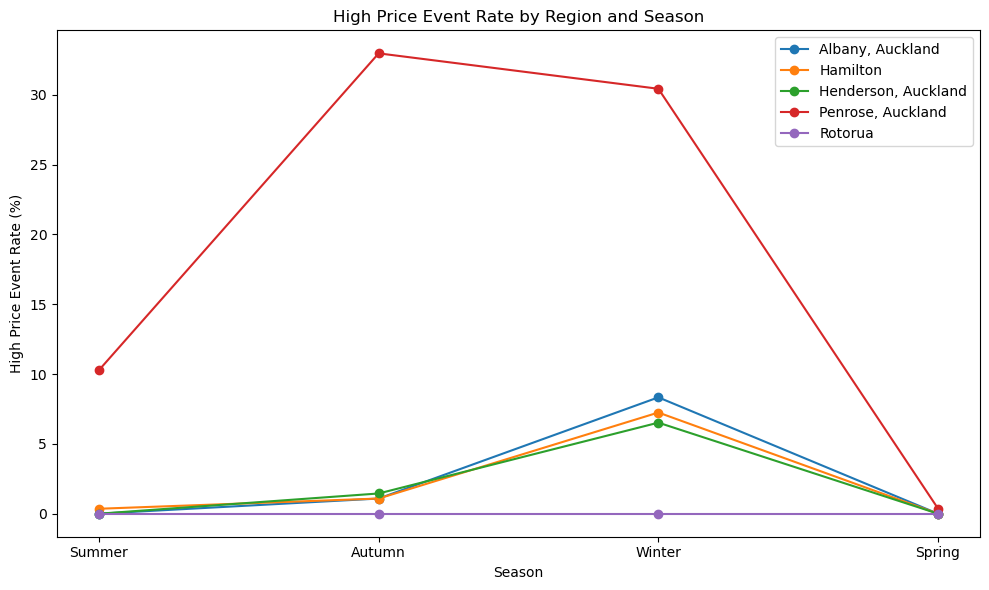

In [40]:
for place in region_season_summary["place"].unique():
    temp = region_season_summary[region_season_summary["place"] == place]
    
    plt.plot(
        temp["season"],
        temp["high_price_rate"],
        marker="o",
        label=place
    )

plt.xlabel("Season")
plt.ylabel("High Price Event Rate (%)")
plt.title("High Price Event Rate by Region and Season")
plt.legend()
plt.tight_layout()
plt.show()

The high-price event rate differs strongly across both regions and seasons. Penrose, Auckland has the highest high-price event rate in the dataset. Its event rate is above 30% in autumn and remains very high in winter. This suggests that high-price events are highly concentrated in Penrose rather than being evenly distributed across all regions. Other regions, such as Albany, Hamilton, and Henderson, show much lower high-price event rates. Their rates increase slightly in winter, but the chances are still much lower than that of Penrose. Rotorua has almost no high-price events across all seasons.

**Summary:** Penrose, Auckland has the highest total electricity price, highest demand, and highest high-price event rate. This suggests that it is the main high-demand and high-risk electricity node in the dataset. Its high values may be linked to industrial and commercial electricity use, rather than only residential demand. Seasonal effects also matter, especially in autumn and winter, when high-price events become more frequent. Therefore, regional demand differences and seasonal pressure jointly explain the variation in electricity value and high-price event risk across regions.

#### Q4. Under what combinations of demand, weather conditions, and regional factors are extreme electricity price spikes most likely to occur?

In [41]:
# Define extreme electricity value threshold
spike_threshold = df['total_electricity_value'].quantile(0.95)
print("Extreme spike threshold:")
print(spike_threshold)

Extreme spike threshold:
924050.202


The top 5% of total electricity values were classified as extreme spikes. This threshold identified 277 spike observations out of 5535 total observations. This makes the analysis focus on unusually high electricity market activity while still keeping enough data for comparison.

In [42]:
# Create spike category
df['spike_category'] = 'Normal'
df.loc[df['total_electricity_value'] > spike_threshold, 'spike_category'] = 'Extreme Spike'
df['spike_category'].value_counts()

spike_category
Normal           5258
Extreme Spike     277
Name: count, dtype: int64

In [43]:
# Extract extreme spike observations
spike_df = df[df['spike_category'] == 'Extreme Spike']
print(spike_df.shape)

(277, 24)


In [44]:
# Compare average conditions
spike_summary = df.groupby('spike_category')[[
    'total_electricity_value',
    'demand_gwh',
    'temp_mean',
    'wind_speed',
    'humidity',
    'precipitation'
]].mean()
spike_summary

,total_electricity_value,demand_gwh,temp_mean,wind_speed,humidity,precipitation
spike_category,,,,,,
Extreme Spike,1.360309e+06,3.421458,13.588809,13.544765,81.386282,3.197473
Normal,2.577977e+05,1.737954,14.934614,14.209243,80.876949,4.065976


Weather conditions do not change as dramatically as electricity demand during spike periods. Electricity demand during extreme spikes is almost twice as high as during normal periods, suggesting that demand pressure is strongly associated with unusually high electricity market activity. In comparison, weather variables show smaller differences. Extreme spike periods tend to have slightly lower temperatures and wind speeds, while humidity levels are marginally higher on average. This may indicate that weather conditions have some influence on electricity market activity, although demand appears to play a much larger role in extreme spike events.

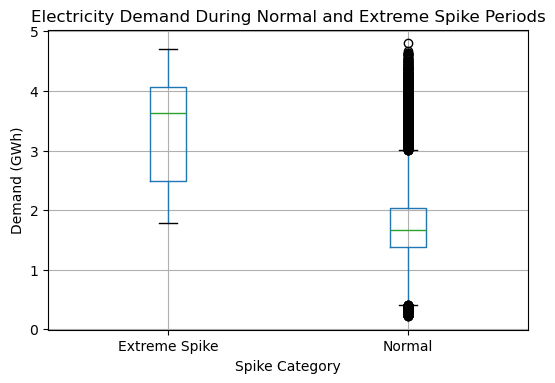

In [45]:
# Compare demand distributions
df.boxplot(column='demand_gwh', by='spike_category', figsize=(6, 4))
plt.title('Electricity Demand During Normal and Extreme Spike Periods')
plt.suptitle('')
plt.xlabel('Spike Category')
plt.ylabel('Demand (GWh)')
plt.show()

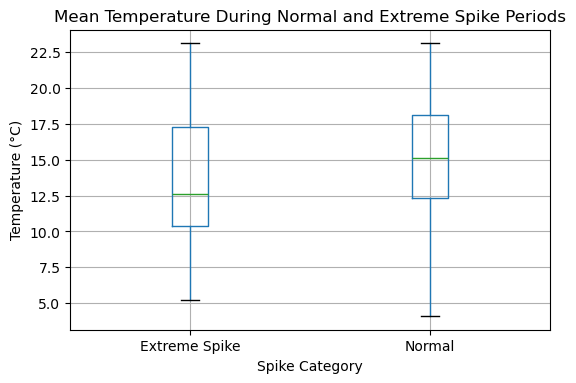

In [46]:
# Compare temperature distributions
df.boxplot(column='temp_mean', by='spike_category', figsize=(6, 4))
plt.title('Mean Temperature During Normal and Extreme Spike Periods')
plt.suptitle('')
plt.xlabel('Spike Category')
plt.ylabel('Temperature (°C)')
plt.show()

The boxplots show clear differences between normal periods and extreme spike periods.

**From the first boxplot,** we can see that electricity demand is substantially higher during extreme spikes, with the median demand level noticeably above that of normal observations. The demand distribution during spike periods is also more concentrated at higher values. This suggests that high demand plays an important role in extreme electricity market activity.

**From the second boxplot,** temperature patterns are less dramatic, but extreme spike periods generally occur at lower temperatures compared with normal periods. This may indicate that colder conditions contribute to increased electricity usage, which may place additional pressure on the electricity market during spike periods.

In [47]:
# Create demand categories
demand_threshold = df['demand_gwh'].quantile(0.75)
df['high_demand'] = 'Normal Demand'
df.loc[df['demand_gwh'] >= demand_threshold, 'high_demand'] = 'High Demand'

In [48]:
# Cross-tabulation between demand level and spike category
demand_crosstab = pd.crosstab(df['high_demand'], df['spike_category'], margins=True)
demand_crosstab

spike_category,Extreme Spike,Normal,All
high_demand,,,
High Demand,239,1146,1385
Normal Demand,38,4112,4150
All,277,5258,5535


In [49]:
# Proportion of spikes under different demand levels
demand_proportion = pd.crosstab(df['high_demand'], df['spike_category'], normalize='index')
demand_proportion

spike_category,Extreme Spike,Normal
high_demand,,
High Demand,0.172563,0.827437
Normal Demand,0.009157,0.990843


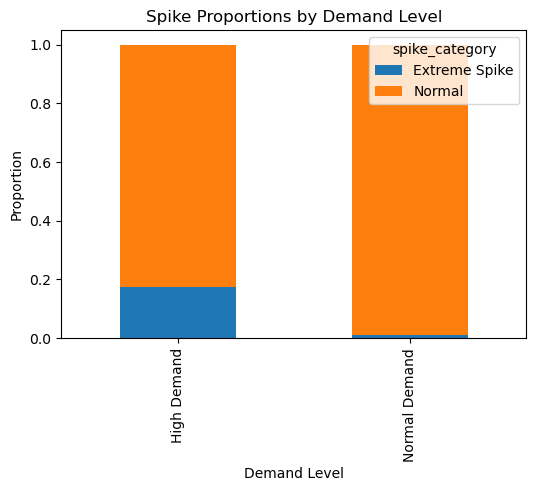

In [50]:
# Visualise spike proportions by demand level
demand_proportion.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Spike Proportions by Demand Level')
plt.xlabel('Demand Level')
plt.ylabel('Proportion')
plt.show()

From the cross-tabulation table, 239 out of 1385 high-demand observations were classified as extreme spikes. That is around 17% of all high-demand periods. For normal-demand periods, only 38 out of 4150 observations were classified as extreme spikes, which is less than 1%. This difference is pretty obvious in the stacked bar chart as well. The high-demand category has a much larger spike proportion, while extreme spikes are rarely seen during normal-demand periods. Looking at both the table and the chart together, extreme electricity spikes happen far more often when electricity demand is high.

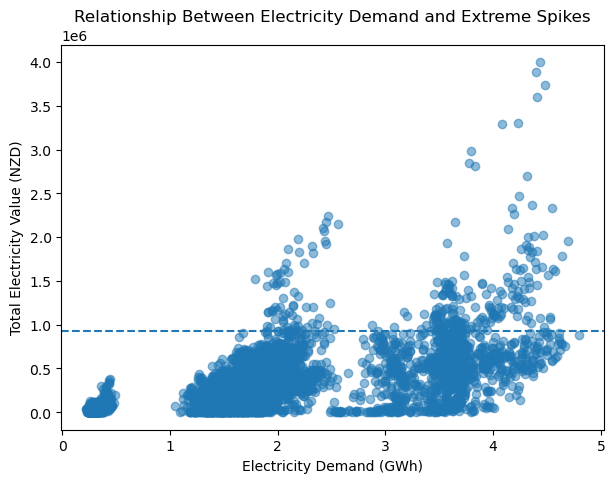

In [51]:
# Relationship between demand and electricity spikes
plt.figure(figsize=(7, 5))
plt.scatter(
    df['demand_gwh'],
    df['total_electricity_value'],
    alpha=0.5
)
plt.axhline(
    spike_threshold,
    linestyle='--'
)
plt.title('Relationship Between Electricity Demand and Extreme Spikes')
plt.xlabel('Electricity Demand (GWh)')
plt.ylabel('Total Electricity Value (NZD)')
plt.show()

From the scatter plot, we can clearly see that most lower-demand observations stay below the spike threshold line, especially when electricity demand is under 2 GWh. Once demand becomes higher, extreme spikes appear much more frequently. The largest spike values are mostly concentrated between around 3 and 5 GWh. However, there are still some high-demand observations that do not become extreme spikes. This means electricity demand is important, but it is probably not the only factor affecting spike events.

In [52]:
# Create high humidity category
humidity_threshold = df['humidity'].quantile(0.75)
df['high_humidity'] = 'Normal Humidity'
df.loc[df['humidity'] >= humidity_threshold, 'high_humidity'] = 'High Humidity'
# Create low wind category
wind_threshold = df['wind_speed'].quantile(0.25)
df['low_wind'] = 'Normal Wind'
df.loc[df['wind_speed'] <= wind_threshold, 'low_wind'] = 'Low Wind'

In [53]:
# Analyse combinations of demand and weather conditions
combination_summary = pd.crosstab(
    [df['high_demand'],
     df['high_humidity'],
     df['low_wind']],
    df['spike_category'],
    normalize='index'
)
combination_summary

spike_category                             Extreme Spike    Normal
high_demand   high_humidity   low_wind                            
High Demand   High Humidity   Low Wind          0.288136  0.711864
                              Normal Wind       0.184971  0.815029
              Normal Humidity Low Wind          0.223214  0.776786
                              Normal Wind       0.141379  0.858621
Normal Demand High Humidity   Low Wind          0.013468  0.986532
                              Normal Wind       0.010976  0.989024
              Normal Humidity Low Wind          0.005355  0.994645
                              Normal Wind       0.009186  0.990814

From the combination analysis table, the highest spike proportion appears under the combination of high demand, high humidity, and low wind conditions, where almost 29% of observations were classified as extreme spikes. Under high-demand conditions, spike proportions remain relatively high even when humidity or wind conditions change. When demand is normal, the spike proportions stay very low across all weather combinations. Looking across the table, electricity demand plays a much larger role than weather conditions in extreme spike events. High humidity and lower wind speeds are still more common in the combinations with the highest spike proportions.

In [54]:
# Compare average weather conditions during spikes
weather_summary = df.groupby('spike_category')[['demand_gwh', 'temp_mean', 'humidity', 'wind_speed', 'precipitation']].mean()
weather_summary

,demand_gwh,temp_mean,humidity,wind_speed,precipitation
spike_category,,,,,
Extreme Spike,3.421458,13.588809,81.386282,13.544765,3.197473
Normal,1.737954,14.934614,80.876949,14.209243,4.065976


The average weather conditions during spike periods are slightly different from normal periods. Electricity demand during extreme spikes is almost twice as high as during normal periods, which is still the biggest difference in the table. Temperature and wind speed are both a little lower during spike periods, while humidity is slightly higher on average. These differences are not very large, but they follow a similar pattern to the earlier combination analysis results.

In [55]:
# Count extreme spikes by node
spike_counts = spike_df['node'].value_counts()
spike_counts

node
PEN0331    205
ALB0331     26
HAM0331     24
HEN0331     22
Name: count, dtype: int64

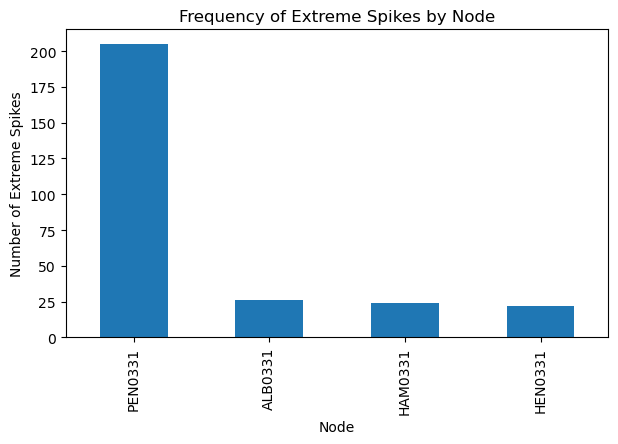

In [56]:
# Visualise regional spike frequency
spike_counts.plot(kind='bar', figsize=(7, 4))
plt.title('Frequency of Extreme Spikes by Node')
plt.xlabel('Node')
plt.ylabel('Number of Extreme Spikes')
plt.show()

In [57]:
regional_summary = spike_df.groupby('node')[['total_electricity_value', 'demand_gwh', 'temp_mean', 'humidity']].mean()
regional_summary

,total_electricity_value,demand_gwh,temp_mean,humidity
node,,,,
ALB0331,1.327021e+06,2.168077,10.753846,83.384615
HAM0331,1.351732e+06,2.221667,9.016667,83.625000
HEN0331,1.299741e+06,2.025682,10.213636,83.409091
PEN0331,1.372034e+06,3.870678,14.845854,80.653659


The regional analysis shows that PEN0331 experienced far more extreme spike events than the other nodes. From the bar chart, the number of spike events at PEN0331 is substantially higher, while the remaining nodes have relatively similar spike frequencies. Looking at the regional summary table, PEN0331 also has the highest average electricity demand during spike periods, with an average demand of around 3.87 GWh. The weather conditions across nodes are fairly similar, so the large difference in spike frequency appears to be more closely related to electricity demand than regional weather differences.

**Summary:** Looking across the analysis, extreme spikes happen much more often during high-demand periods. The spike proportions become even higher when humidity is high and wind speeds are lower. PEN0331 also stands out from the other nodes, with far more extreme spike events than the other regions. High-demand observations consistently showed much larger spike proportions than normal-demand periods. Weather conditions also appeared to play some role, although the differences were generally smaller than the differences in electricity demand. PEN0331 had the highest average electricity demand during spike periods, which may help explain why extreme spikes were much more common at this node.

# Conclusion 
Overall, the analysis shows that electricity value and high-price events in New Zealand are strongly linked to demand, season, and region. The correlation matrix shows a moderate positive relationship between electricity demand and total electricity value, suggesting that higher demand is generally associated with higher electricity value. However, the relationship is not perfectly explained by simple linear correlations, especially for weather variables.

Seasonal patterns are clear. Electricity demand and total electricity price both increase during winter, especially in July and August. High-price events are also more common during this period which suggests that electricity price variation is affected by the demand of electricity in winter. However, extreme spikes cannot be explained by demand alone, because weather conditions and market factors may also contribute.

Regional differences are also important. Penrose, Auckland has the highest electricity demand, highest total electricity price, and highest high-price event rate. This indicates that Penrose is the main high-demand and high-risk electricity node in the dataset. Its high demand may be related to industrial and commercial electricity use, rather than only residential consumption. Other regions, such as Albany, Hamilton, and Henderson, show lower demand and lower high-price event rates, while Rotorua has the lowest values.

The analysis also suggests that extreme price spikes are more likely to occur under specific combinations of conditions. High-demand periods show much larger spike proportions than normal-demand periods. The spike rate also appears to increase when humidity is higher and wind speed is lower, although these weather effects are smaller than the demand and regional effects. PEN0331 stands out as the node with the most extreme spike events, which may be explained by its much higher average demand.

In conclusion, electricity value and high-price event risk are shaped by a combination of high demand, seasonal pressure, regional demand structure, and some weather conditions. Demand appears to be the strongest factor, especially in winter and at the Penrose node. 

### Key findings:

1. There is a positive relationship between the demand of electricity and total electricity price, but there is not any clear relationship between the demand and weather conditions including temperature, humidity, and precipitation.
2. In winter, people use more electricity than other seasons, so that higher total electricity price, espically in August.
3. Regional demand differences and seasonal pressure together explain the variation in electricity value and high-price event risk across regions. 
4. Extreme electricity price spikes most likely to occur at Penrose, Auckland, when there is high demand, high humidity, and low wind.
5. Penrose, Auckland has much higher electricity demand than the other Auckland regions. This may be because Penrose is an important industrial and grid supply area rather than only a residential suburb. The Penrose grid node likely serves a large industrial and commercial load, including manufacturing, logistics, warehousing, and other high-consumption activities.
6. According to the Electricity Authority, New Zealand’s wholesale electricity prices increased from roughly 300 NZD/MWh in early July 2024 to up to 820 NZD/MWh in early August 2024. This suggests that the price spike observed in the dataset around August 2024 matches a wider national wholesale electricity price event, rather than being only a data error.